# Module 7: Vector Fields & Atmospheric Dynamics — Monsoon Winds and Jet Streams

Atmospheric motions are vector fields defined by orthogonal components:
* **$u$ (Zonal Wind):** Velocity along the East-West axis (positive = Westerly, blowing from West to East).
* **$v$ (Meridional Wind):** Velocity along the North-South axis (positive = Southerly, blowing from South to North).

### 1. Vector Magnitude: Wind Speed
Scalar wind speed ($|\vec{V}|$) is computed using the Euclidean norm:

$$|\vec{V}| = \sqrt{u^2 + v^2}$$

### 2. Synoptic Regimes We Will Explore:
1. **Low-Level Monsoon Flow (850 hPa):** The Somali Jet / Southwesterly monsoon winds carrying moisture into India during July.
2. **Upper-Tropospheric Jet Stream (200 hPa):** Subtropical Westerly Jet (Winter) vs. Tropical Easterly Jet (Summer).

In [5]:
import os
import cartopy.crs as ccrs
from cartopy.mpl.ticker import LatitudeFormatter, LongitudeFormatter
import cartopy.io.shapereader as shpreader
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

# Load 3D monthly wind datasets
# data_dir = '/mnt/5GLab2/ClimData/NCEP/3d/'
ds_u = xr.open_dataset('data/uwnd.mon.mean.nc')
ds_v = xr.open_dataset('data/vwnd.mon.mean.nc')

# 1. Clean and sort latitudes
u_raw = ds_u['uwnd']
v_raw = ds_v['vwnd']

if u_raw.lat[0] > u_raw.lat[-1]:
  u_raw = u_raw.sortby('lat')
if v_raw.lat[0] > v_raw.lat[-1]:
  v_raw = v_raw.sortby('lat')

# 2. Extract July Climatology at 850 hPa (Low-Level Monsoon Flow)
u_850_jul = (
    u_raw.sel(level=850).groupby('time.month').mean(dim='time').sel(month=7)
)
v_850_jul = (
    v_raw.sel(level=850).groupby('time.month').mean(dim='time').sel(month=7)
)

# 3. Calculate 850 hPa Wind Speed Magnitude
wspd_850_jul = np.sqrt(u_850_jul**2 + v_850_jul**2)
wspd_850_jul.attrs['units'] = 'm/s'

print('Wind components extracted successfully at 850 hPa.')
print(
    f'Max July 850 hPa Wind Speed over Domain: {float(wspd_850_jul.max()):.2f}'
    ' m/s'
)

Wind components extracted successfully at 850 hPa.
Max July 850 hPa Wind Speed over Domain: 20.17 m/s


### 3. Vector Quiver Plots with Reference Keys (`ax.quiver`)

When plotting vector arrows:
1. **Grid Thinning (`skip = (slice(...), slice(...))`):** Plotting an arrow at every single grid cell clutters the map. We stride the coordinate axes.
2. **Reference Key (`ax.quiverkey`):** Never plot vector arrows without an explicit scale key indicating arrow magnitude (e.g., $10\text{ m/s}$).

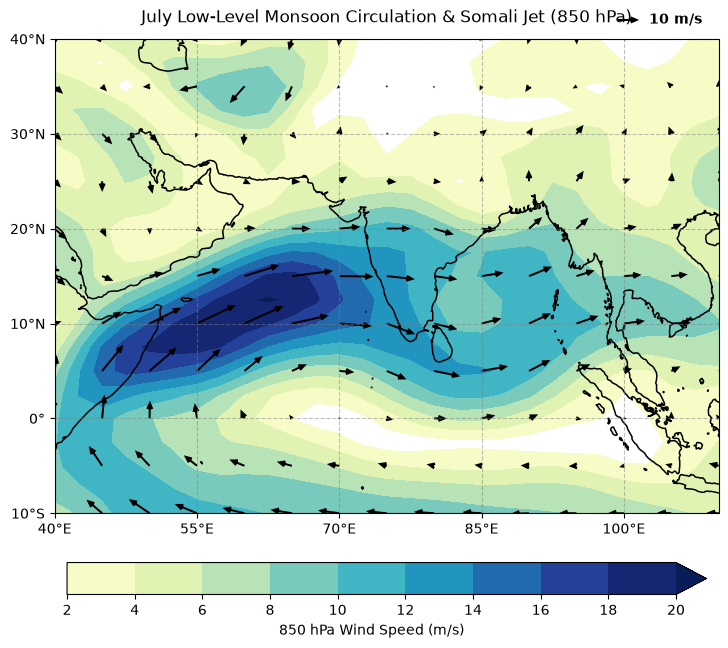

In [6]:
# 1. Load local coastline shapefile
shp_path = os.path.expanduser(
    '~/.local/share/cartopy/shapefiles/natural_earth/physical/ne_50m_coastline.shp'
)
coastline_geometries = (
    list(shpreader.Reader(shp_path).geometries())
    if os.path.exists(shp_path)
    else []
)

# 2. Slice for Indian Ocean / South Asian Monsoon domain
domain = dict(lat=slice(-15, 45), lon=slice(35, 115))
u_sub = u_850_jul.sel(domain)
v_sub = v_850_jul.sel(domain)
wspd_sub = wspd_850_jul.sel(domain)

# 3. Setup Figure
fig = plt.figure(figsize=(11, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([40, 110, -10, 40], crs=ccrs.PlateCarree())

# Background: Shaded Wind Speed
speed_levels = np.arange(2, 22, 2)
cf = ax.contourf(
    wspd_sub.lon.values,
    wspd_sub.lat.values,
    wspd_sub.values,
    levels=speed_levels,
    cmap='YlGnBu',
    transform=ccrs.PlateCarree(),
    extend='max',
)

# Vector Overlay (Quivers) — step by 2 grid cells for readability
step = 2
lon_q = u_sub.lon.values[::step]
lat_q = u_sub.lat.values[::step]
u_q = u_sub.values[::step, ::step]
v_q = v_sub.values[::step, ::step]

q = ax.quiver(
    lon_q,
    lat_q,
    u_q,
    v_q,
    transform=ccrs.PlateCarree(),
    color='black',
    scale=300,
    width=0.003,
    headwidth=3.5,
    headlength=4,
)

# Vector Reference Key
ax.quiverkey(
    q,
    X=0.88,
    Y=1.04,
    U=10,
    label='10 m/s',
    labelpos='E',
    coordinates='axes',
    fontproperties={'size': 10, 'weight': 'bold'},
)

# Add Coastlines
if coastline_geometries:
  ax.add_geometries(
      coastline_geometries,
      crs=ccrs.PlateCarree(),
      edgecolor='black',
      facecolor='none',
      linewidth=1.1,
  )

# Formatting
ax.set_xticks(np.arange(40, 111, 15), crs=ccrs.PlateCarree())
ax.set_yticks(np.arange(-10, 41, 10), crs=ccrs.PlateCarree())
ax.xaxis.set_major_formatter(LongitudeFormatter())
ax.yaxis.set_major_formatter(LatitudeFormatter())
ax.grid(True, linestyle='--', color='gray', alpha=0.5)

# Colorbar
cbar = plt.colorbar(cf, ax=ax, orientation='horizontal', pad=0.08, shrink=0.75)
cbar.set_label('850 hPa Wind Speed (m/s)', fontsize=10)

plt.title(
    'July Low-Level Monsoon Circulation & Somali Jet (850 hPa)',
    fontsize=12,
    pad=12,
)
plt.show()

### 4. Streamline Plots (`ax.streamplot`)

While quivers display discrete arrows at sampled grid points, **streamlines** trace the continuous tangent trajectories of the vector field, making convergence zones and circulation centers (cyclones/anticyclones) instantly visible.

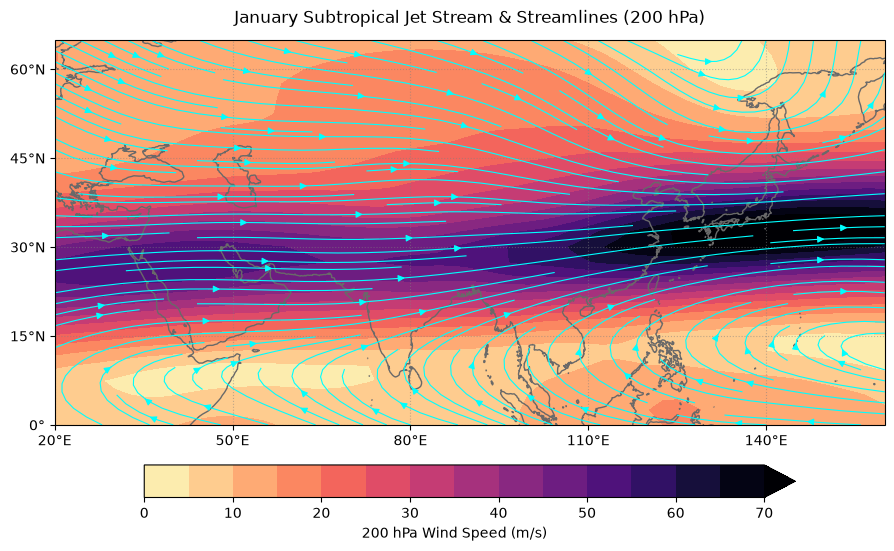

In [8]:
import cartopy.crs as ccrs
from cartopy.mpl.ticker import LatitudeFormatter, LongitudeFormatter
import matplotlib.pyplot as plt
import numpy as np

# Global / Hemispheric Domain for Jet Stream
sub_jet = dict(lat=slice(0, 70), lon=slice(0, 180))
lon_s = u_200_jan.sel(sub_jet).lon.values
lat_s = u_200_jan.sel(sub_jet).lat.values
u_s = u_200_jan.sel(sub_jet).values
v_s = v_200_jan.sel(sub_jet).values
w_s = wspd_200_jan.sel(sub_jet).values

fig = plt.figure(figsize=(12, 6.5))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([20, 160, 0, 65], crs=ccrs.PlateCarree())

# 1. Full contour range starting from 0 m/s
jet_levels = np.arange(0, 75, 5)

cf = ax.contourf(
    lon_s,
    lat_s,
    w_s,
    levels=jet_levels,
    cmap='magma_r',
    transform=ccrs.PlateCarree(),
    extend='max',
)

# 2. Overlay Streamlines
ax.streamplot(
    lon_s,
    lat_s,
    u_s,
    v_s,
    transform=ccrs.PlateCarree(),
    color='cyan',  # Cyan or lightgray stands out clearly against magma_r
    linewidth=0.8,
    density=1.2,
    arrowsize=1.0,
)

# 3. Add Coastlines
if coastline_geometries:
  ax.add_geometries(
      coastline_geometries,
      crs=ccrs.PlateCarree(),
      edgecolor='dimgray',
      facecolor='none',
      linewidth=1.0,
  )

# 4. Ticks and Labels
ax.set_xticks(np.arange(20, 161, 30), crs=ccrs.PlateCarree())
ax.set_yticks(np.arange(0, 66, 15), crs=ccrs.PlateCarree())
ax.xaxis.set_major_formatter(LongitudeFormatter())
ax.yaxis.set_major_formatter(LatitudeFormatter())
ax.grid(True, linestyle=':', color='gray', alpha=0.5)

cbar = plt.colorbar(cf, ax=ax, orientation='horizontal', pad=0.08, shrink=0.7)
cbar.set_label('200 hPa Wind Speed (m/s)', fontsize=10)

plt.title(
    'January Subtropical Jet Stream & Streamlines (200 hPa)', fontsize=12, pad=12
)
plt.show()